# Tutorial – Session 8

## Hypotesetest

Denne tutorial følger **Ross, kapitel 8**, afsnit **8.1**, **8.2**, **8.3**, **8.4** og **8.6** (jf. sessionbeskrivelsen). Afsnit **8.5** (test af varians med $\chi^2$) og **8.7** (Poisson) er **ikke** med. For hvert emne gives først de centrale formler og fortolkninger, derefter **Python**-eksempler med `numpy`, `scipy.stats` og `matplotlib`.


**Konfidensintervaller** (én middelværdi, forskel mellem middelværdier, andele): se **Tutorial 7** — særligt afsnit **3.2** ($t$-CI), **6** ($\mu_1-\mu_2$ pooled) og **7** (andel med Wald). Her supplerer vi med det, I typisk skal bruge **sammen med hypotesetest** i session 8’s øvelser.

**Normal probability plot (QQ):** udvidet teori og fortolkning i **Tutorial 7, afsnit 2** og [plot_normal_distribution.ipynb](../07_Intervalestimation_og_konfidensintervaller/plot_normal_distribution.ipynb). Nedenfor er et minimalt kodeeksempel, så I kan plotte uden at skifte fil.

---

## 1. Introduktion og opsætning

Biblioteker:

- `numpy`, `pandas` (fx `read_excel`, `Series.plot.kde`)
- `scipy.stats` — tests, `probplot`, `skew`, `kurtosis`, `levene`
- `matplotlib.pyplot`



In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import (
    norm,
    t,
    binomtest,
    ttest_1samp,
    ttest_ind,
    ttest_rel,
    probplot,
    skew,
    kurtosis,
    levene,
)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
plt.style.use("ggplot")



---

## 2. QQ-plot (normalitetscheck, som i øvelse 1–2 og 8)



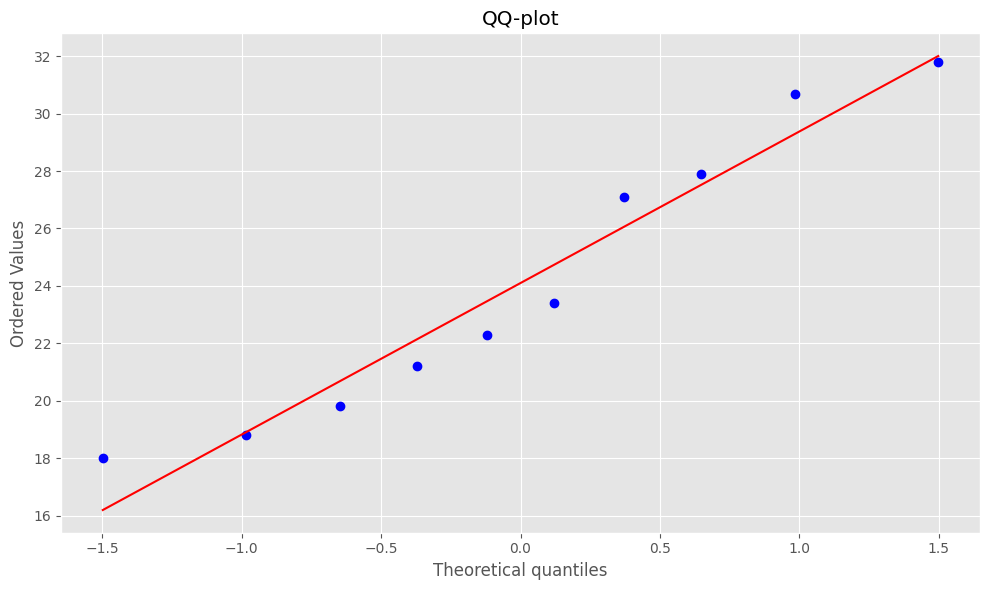

In [20]:
x = np.array([18.0, 30.7, 19.8, 27.1, 22.3, 18.8, 31.8, 23.4, 21.2, 27.9])
fig, ax = plt.subplots()
probplot(x, dist="norm", plot=ax)
ax.set_title("QQ-plot")
plt.tight_layout()
plt.show()



For **parrede** data (øvelse 6) tjekkes ofte **normalitet af differenser** $d_i = x_i - y_i$ — samme kode med `d` i stedet for `x`.

---

## 3. Grundbegreber (Ross 8.1)

- **$H_0$ / $H_1$**, ensidet/tosidet, **p-værdi**, $\alpha$, type I- og type II-fejl.



In [21]:
alpha = 0.05
z_crit = norm.ppf(1 - alpha / 2)
z_obs = 2.1
p_two = 2 * (1 - norm.cdf(abs(z_obs)))
print(f"Tosidet z: forkast |z| > {z_crit:.3f}; p = {p_two:.4f}")


Tosidet z: forkast |z| > 1.960; p = 0.0357



---

## 4. $z$-test for $\mu$, $\sigma$ kendt (Ross 8.2)



In [22]:
x = np.array([98.5, 101.2, 99.8, 100.4, 99.1])
mu0, sigma, alpha = 100.0, 2.0, 0.05
n = len(x)
xbar = np.mean(x)
se = sigma / np.sqrt(n)
z_obs = (xbar - mu0) / se
print(f"z_obs={z_obs:.4f}, p(tosidet)={2 * (1 - norm.cdf(abs(z_obs))):.4f}")


z_obs=-0.2236, p(tosidet)=0.8231



---

## 5. $t$-test, én stikprøve (Ross 8.3) — tosidet og ensidet

$$T = \frac{\bar{X}-\mu_0}{S/\sqrt{n}} \sim t_{n-1} \quad \text{(under } H_0 \text{ og normalitet).}$$

**Øvelse 1** (regn med, at middelværdi ** overstiger** 25): ensidet alternativ `"greater"`. **Øvelse 2**: tosidet.



In [23]:
# Eksempel som øvelse 1 (regnemedregn: tilpas dine tal)
rain = np.array(
    [
        18.0, 30.7, 19.8, 27.1, 22.3, 18.8, 31.8, 23.4, 21.2, 27.9,
        31.9, 27.1, 25.0, 24.7, 26.9, 21.8, 29.2, 34.8, 26.7, 31.6,
    ]
)
mu0, alpha = 25.0, 0.01
t_stat, p_greater = ttest_1samp(rain, mu0, alternative="greater")
print(f"Ensidet H1 mu > {mu0}: t={t_stat:.4f}, p={p_greater:.4f}")

# Tosidet (som øvelse 2)
body = np.array(
    [
        97.8, 97.2, 97.4, 97.6, 97.8, 97.9, 98.0, 98.0, 98.0, 98.1,
        98.2, 98.3, 98.3, 98.4, 98.4, 98.4, 98.5, 98.6, 98.6, 98.7,
        98.8, 98.8, 98.9, 98.9, 99.0,
    ]
)
t_stat2, p_two = ttest_1samp(body, 98.6, alternative="two-sided")
print(f"Tosidet: t={t_stat2:.4f}, p={p_two:.4f}")


Ensidet H1 mu > 25.0: t=0.9674, p=0.1728
Tosidet: t=-3.4849, p=0.0019



**Ensidet konfidensgrænse for $\mu$** ($t$, ukendt $\sigma$): som i Tutorial 7.3.2 — $\bar{x} - t_{\alpha,\,n-1}\,s/\sqrt{n} \leq \mu$ for **nedre** grænse med konfidens $1-\alpha$.

---

## 6. To uafhængige stikprøver — middelværdier (Ross 8.4)

$$S_p^2 = \frac{(n_1-1)S_1^2+(n_2-1)S_2^2}{n_1+n_2-2}, \quad
T = \frac{\bar{X}_1-\bar{X}_2}{S_p\sqrt{1/n_1+1/n_2}} \sim t_{n_1+n_2-2} \text{ under } H_0.$$

**Valgfrit før pooled $t$:** test af ens varianser med **Levene** (eller $F$-forhold $s_1^2/s_2^2$) — som i nogle eksamensløsninger.



In [24]:
a = np.array([5.1, 6.2, 4.8, 5.5, 5.9])
b = np.array([4.2, 5.0, 4.5, 4.8, 5.1, 4.9])
stat_lv, p_lv = levene(a, b)
print(f"Levene ens varians: p={p_lv:.4f}")

t_stat, p_ind = ttest_ind(a, b, equal_var=True)
print(f"ttest_ind (pooled): t={t_stat:.4f}, p={p_ind:.4f}")
t_stat_w, p_w = ttest_ind(a, b, equal_var=False)
print(f"Welch: t={t_stat_w:.4f}, p={p_w:.4f}")


Levene ens varians: p=0.2522
ttest_ind (pooled): t=2.7136, p=0.0239
Welch: t=2.5852, p=0.0399



**95 %-CI for $\mu_1 - \mu_2$ (pooled)** — samme formel som Tutorial 7.6:



In [25]:
def ci_diff_means_pooled(x1, x2, confidence=0.95):
    x1, x2 = np.asarray(x1, float), np.asarray(x2, float)
    n1, n2 = len(x1), len(x2)
    m1, m2 = np.mean(x1), np.mean(x2)
    v1, v2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    df = n1 + n2 - 2
    sp = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / df)
    se = sp * np.sqrt(1 / n1 + 1 / n2)
    alpha = 1 - confidence
    tcrit = t.ppf(1 - alpha / 2, df)
    diff = m1 - m2
    return diff - tcrit * se, diff + tcrit * se

ci_lower, ci_upper = ci_diff_means_pooled(a, b)
print(f"95% CI mu1-mu2: [{ci_lower:.4f}, {ci_upper:.4f}]")


95% CI mu1-mu2: [0.1248, 1.3752]



---

## 7. Parret $t$-test og CI for middel af differenser (Ross 8.4)

**Øvelse 5** (samme patient, to maskiner) er **parret** design: brug **differenser** og `ttest_rel` — ikke `ttest_ind` på de to kolonner som uafhængige stikprøver.

**Øvelse 6** (før/efter): samme idé.



In [26]:
machine_a = np.array([119, 130, 141, 123, 149, 156, 134, 108, 123, 138, 119, 156])
machine_b = np.array([112, 126, 145, 112, 138, 156, 130, 112, 112, 119, 112, 152])
d = machine_a - machine_b
t_stat, p_rel = ttest_rel(machine_a, machine_b)
print(f"Parret t (H0: middel differens=0): t={t_stat:.4f}, p={p_rel:.4f}")

# 95 % CI for middel af differenser
n, alpha = len(d), 0.05
dbar = np.mean(d)
sd = np.std(d, ddof=1)
se = sd / np.sqrt(n)
tcrit = t.ppf(1 - alpha / 2, n - 1)
print(f"95% CI for E[D]: [{dbar - tcrit * se:.4f}, {dbar + tcrit * se:.4f}]")


Parret t (H0: middel differens=0): t=3.0164, p=0.0117
95% CI for E[D]: [1.5769, 10.0898]



---

## 8. Test for én andel — stor stikprøve (Ross 8.6)

$$Z = \frac{\hat{p} - p_0}{\sqrt{p_0(1-p_0)/n}}.$$

**Øvelse 3:** ensidet $H_1: p > p_0$. **Øvelse 4:** tosidet.



In [27]:
# Øvelse 3: x=289, n=350, p0=0.78, ensidet større
x, n, p0, alpha = 289, 350, 0.78, 0.05
phat = x / n
se0 = np.sqrt(p0 * (1 - p0) / n)
z0 = (phat - p0) / se0
p_one = norm.sf(z0)
print(f"z={z0:.4f}, p (ensidet >)={p_one:.4f}")

# Øvelse 4: tosidet test for p = 0.5
x4, n4, p0 = 117, 484, 0.5
ph4 = x4 / n4
z4 = (ph4 - p0) / np.sqrt(p0 * (1 - p0) / n4)
p_tosidet = 2 * min(norm.cdf(z4), norm.sf(z4))
print(f"Øvelse 4: z={z4:.4f}, p(tosidet)≈{p_tosidet:.4e}")
print(f"binomtest: p={binomtest(x4, n4, p=p0, alternative='two-sided').pvalue:.4e}")


z=2.0646, p (ensidet >)=0.0195
Øvelse 4: z=-11.3636, p(tosidet)≈6.3448e-30
binomtest: p=4.4584e-31



**Ensidet nedre CI for $p$** med $\hat{p}$ i standardfejl (som i øvelse 3, svar): $\hat{p} - z_\alpha\sqrt{\hat{p}(1-\hat{p})/n}$ — se **Tutorial 7.7** (`side="lower"`). **Tosidet Wald-CI** med $\hat{p}$ i SE: Tutorial 7.7 `side="two"`.

---

## 9. Test for to andele (Ross 8.6, øvelse 7)

Under $H_0: p_1=p_2$: $\hat{p} = (x_1+x_2)/(n_1+n_2)$,

$$Z = \frac{\hat{p}_1-\hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})(1/n_1+1/n_2)}}.$$



In [28]:
x1, n1 = 92, 98
x2, n2 = 136, 254 - 98
p1h, p2h = x1 / n1, x2 / n2
ph = (x1 + x2) / (n1 + n2)
se = np.sqrt(ph * (1 - ph) * (1 / n1 + 1 / n2))
z_obs = (p1h - p2h) / se
print(f"Ensidet p1 > p2: z={z_obs:.4f}, p={norm.sf(z_obs):.4f}")


Ensidet p1 > p2: z=1.7143, p=0.0432



---

## 10. Dataarbejde, outliers, KDE og CI-figurer (øvelse 8)

**Læs Excel** (filen skal ligge i jeres arbejdsmappe eller angiv fuld sti):



In [29]:
# df = pd.read_excel("Batteries.xlsx")
# df1, df2 = df["Producer 1"], df["Producer 2"]



**Outliers med 1,5×IQR** (erstat med gruppens middelværdi uden outliers, som i opgaven):



In [30]:
def replace_outliers_iqr_mean(series):
    s = series.astype(float)
    q1, q3 = np.percentile(s, [25, 75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s >= low) & (s <= high)
    mu_clean = s[mask].mean()
    return s.where(mask, mu_clean)


rng = np.random.default_rng(0)
fake1 = pd.Series(rng.normal(2, 0.9, 30))
clean1 = replace_outliers_iqr_mean(fake1)
print("n=", len(clean1), "mean=", clean1.mean())


n= 30 mean= 1.959048007023847



**Kvartiler, middelværdi, spredning:**



In [31]:
s = clean1
print("q1,q2,q3:", s.quantile([0.25, 0.5, 0.75]).tolist())
print("mean, std, var:", s.mean(), s.std(ddof=1), s.var(ddof=1))


q1,q2,q3: [1.4568314666443924, 1.9216834051871083, 2.3231664278348316]
mean, std, var: 1.959048007023847 0.6390309174267399 0.40836051342726093



**Skævhed og kurtosis** (som i opgavefilerne, ofte med `bias=False` for “population”-stil — følg jeres lærebog):



In [32]:
print("skew, kurtosis:", skew(s, bias=False), kurtosis(s, bias=False))


skew, kurtosis: 0.3133251435858791 -0.543413547168131



**KDE-plot:**



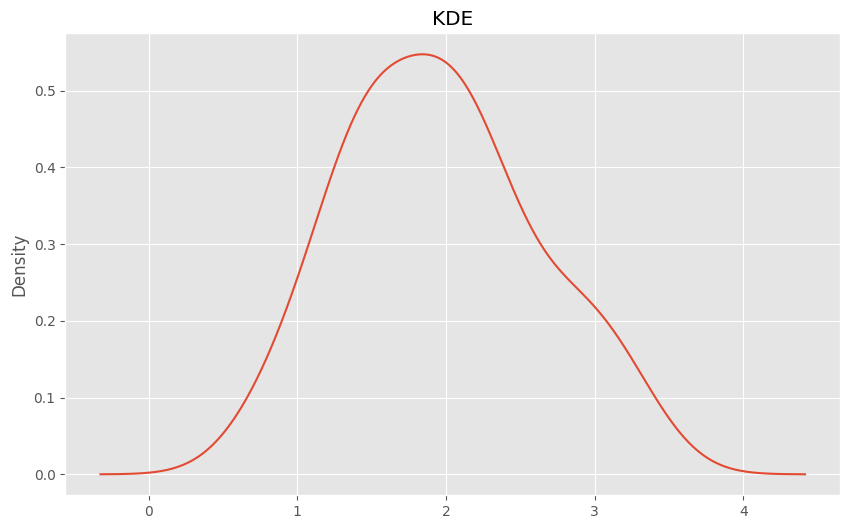

In [33]:
fig, ax = plt.subplots()
s.plot.kde(ax=ax, bw_method=0.5)
ax.set_title("KDE")
plt.show()



**95 %-CI for én middelværdi** med `t.interval`:



In [34]:
def t_ci_mean(x, confidence=0.95):
    x = np.asarray(x, float)
    n = len(x)
    se = np.std(x, ddof=1) / np.sqrt(n)
    return t.interval(confidence, n - 1, loc=np.mean(x), scale=se)


# print(t_ci_mean(df1))



**Figur med $t$-tæthed** (illustration af CI — som i nogle svar; skaler `scale=SE`, `loc=mean`):



In [35]:
def plot_t_ci_on_mean_axis(data, confidence=0.95):
    x = np.asarray(data, float)
    n = len(x)
    mean = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(n)
    df = n - 1
    alpha = 1 - confidence
    tcrit = t.ppf(1 - alpha / 2, df)
    lo, hi = mean - tcrit * se, mean + tcrit * se
    xs = np.linspace(mean - 4 * se, mean + 4 * se, 400)
    ys = t.pdf((xs - mean) / se, df) / se
    fig, ax = plt.subplots()
    ax.plot(xs, ys, "k")
    ax.axvline(lo, ls="--", color="C0")
    ax.axvline(hi, ls="--", color="C0")
    ax.fill_between(xs, ys, where=(xs >= lo) & (xs <= hi), alpha=0.25)
    ax.set_title("t-fordeling (skaleret) og CI for middelværdi")
    plt.show()


# plot_t_ci_on_mean_axis(clean1)



**Hypotesetest for to uafhængige middelværdier** på de to producentkolonner: `ttest_ind(..., equal_var=True)` som i øvelsens del (6).

---

## 11. Oversigt: hypoteser, tests og Python (SciPy)

Samlet reference til de cases, I har set i tutorialen. I `scipy.stats` fortolkes **`alternative`** ud fra **første stikprøve** i `ttest_ind(a, b, …)` (hypotese om $\mu_a$ vs. $\mu_b$) og ud fra **første minus anden** i `ttest_rel(x, y, …)` (hypotese om middel af $x-y$).

### Én middelværdi ($t$- eller $z$-test)

| Situation | Typisk $H_0$ | Python / beregning |
|-----------|--------------|---------------------|
| $\sigma$ **kendt** (normalmodel) | $\mu = \mu_0$ | Manuel: $z_{\mathrm{obs}} = (\bar x - \mu_0)/(\sigma/\sqrt n)$; $p$ med `norm.cdf` / `norm.sf` (tosidet som i afsnit 2). |
| $\sigma$ **ukendt**, **tosidet** | $\mu = \mu_0$ | `ttest_1samp(x, mu0, alternative="two-sided")` |
| $\sigma$ ukendt, **$\mu > \mu_0$** | $\mu = \mu_0$ (eller $\mu \le \mu_0$) | `ttest_1samp(x, mu0, alternative="greater")` |
| $\sigma$ ukendt, **$\mu < \mu_0$** | $\mu = \mu_0$ (eller $\mu \ge \mu_0$) | `ttest_1samp(x, mu0, alternative="less")` |

**Parret** design: brug `ttest_rel(x, y, alternative="two-sided" | "greater" | "less")` eller ækvivalent `ttest_1samp(x - y, 0, alternative=…)` (differenser $x_i - y_i$).

### To uafhængige middelværdier ($t$-test)

| Situation | Typisk $H_0$ | Python / beregning |
|-----------|--------------|---------------------|
| **Pooled** (lige varianser — vejledende tjek: `levene(a, b)`), **tosidet** | $\mu_a = \mu_b$ | `ttest_ind(a, b, equal_var=True, alternative="two-sided")` |
| Pooled, **$\mu_a > \mu_b$** | $\mu_a = \mu_b$ | `ttest_ind(a, b, equal_var=True, alternative="greater")` |
| Pooled, **$\mu_a < \mu_b$** | $\mu_a = \mu_b$ | `ttest_ind(a, b, equal_var=True, alternative="less")` |
| **Welch** (ulige varianser tilladt), samme hypotesetyper | $\mu_a = \mu_b$ | `ttest_ind(a, b, equal_var=False, alternative="two-sided" \| "greater" \| "less")` |

Byt rækkefølgen af `a` og `b`, hvis I vil formulere alternativet med den anden gruppe som “første”.

**95 %-CI for $\mu_1 - \mu_2$** (pooled, som i afsnit 6): `ci_diff_means_pooled(x1, x2)`.

### Andele

| Situation | Typisk $H_0$ | Python / beregning |
|-----------|--------------|---------------------|
| **Én andel**, eksakt (binomialmodel) | $p = p_0$ | `binomtest(k, n, p=p0, alternative="two-sided" \| "greater" \| "less")` ($k$ succeser ud af $n$) |
| **Én andel**, normalapproksimation | $p = p_0$ | Manuel $z$; $p$ med `norm` (afsnit 8) |
| **To andele** (stor stikprøve, pooled $z$) | $p_1 = p_2$ | **Manuel** $z$ og $p$ med `norm` (afsnit 9) — ikke en enkelt kernefunktion i SciPy til den klassiske test |

### Forudsætninger (hjælp, ikke “automatisk sandhed”)

| Formål | Funktion |
|--------|----------|
| Afvigelser fra lige varianser (robust) | `levene(gruppe1, gruppe2)` |
| Normalitet (grafisk) | `probplot` (QQ) — afsnit 3 og 6 |

### Konfidensintervaller (supplerende)

| Parameter | Python / idé |
|-----------|----------------|
| $\mu$ én stikprøve | `t.interval(confidence, n - 1, loc=mean, scale=SE)` (afsnit 10) |
| $\mu_1 - \mu_2$ pooled | `ci_diff_means_pooled(x1, x2)` |
| Én andel $p$ | Se Tutorial 7.7 (fx Wilson); til hypotesetest bruges `binomtest` i denne tutorial |

**Relation test ↔ CI:** En **tosidet** test på niveau $\alpha$ svarer ofte til, at den hypotetiske værdi ligger **uden for** et $100(1-\alpha)\,\%$-konfidensinterval for den tilsvarende parameter.

Øvelsesopgaverne i session 8 bruger kombinationerne ovenfor; detaljer står i de enkelte afsnit og i øvelsesfilerne.
